# Multi-label Classification of Toxic YouTube Comments
**ITCS348 Introduction to Natural Language Processing — Project 1**

**Pipeline Overview:**
1. Problem Definition & Dataset Acquisition
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Feature Extraction
5. Model Implementation (Rule-based → Traditional ML → Deep Learning → Transformer)
6. Evaluation & Comparative Analysis
7. Error Analysis & Ethical Considerations

## ⚙️ Setup — Install & Import Dependencies

In [21]:
# Install required packages
!pip install -q gensim spacy contractions scikit-multilearn
!pip install -q transformers torch
!pip install -q wordcloud

In [22]:
# ── Core Libraries ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import re
import time
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from wordcloud import WordCloud
sns.set_theme(style='whitegrid', palette='muted')

# ── NLP Preprocessing ────────────────────────────────────────────────
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
import contractions

for pkg in ['punkt_tab', 'averaged_perceptron_tagger_eng',
            'stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

# ── Feature Extraction ───────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# ── Traditional ML ───────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.pipeline import Pipeline

# ── Deep Learning ────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (Dense, Dropout, Embedding, LSTM,
                                     Bidirectional, GlobalMaxPooling1D,
                                     Input)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ── Metrics ──────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, f1_score, hamming_loss,
    accuracy_score, roc_auc_score, confusion_matrix
)

print('✅ All imports successful')
print(f'TensorFlow version: {tf.__version__}')

✅ All imports successful
TensorFlow version: 2.19.0


---
## 📌 Phase 1 — Problem Definition & Dataset Acquisition

**Task:** Multi-label text classification — a single YouTube comment can carry *multiple* toxicity labels simultaneously (e.g., a comment can be both *Abusive* and *Obscene*).

**Dataset:** [YouTube Toxicity Dataset (Kaggle)](https://www.kaggle.com/datasets/) — 1,000 English comments annotated with 12 toxicity labels.

**Target Labels selected** (labels with ≥ 50 positive samples to ensure model learnability):

| Label | Count | Prevalence |
|---|---|---|
| IsToxic | 462 | 46.2% |
| IsAbusive | 353 | 35.3% |
| IsProvocative | 161 | 16.1% |
| IsHatespeech | 138 | 13.8% |
| IsRacist | 125 | 12.5% |
| IsObscene | 100 | 10.0% |

> **Justification for dropping other labels:** IsNationalist(8), IsSexist(1), IsHomophobic(0), IsReligiousHate(12), IsRadicalism(0), IsThreat(21) have too few positive samples for reliable multi-label learning with only 1,000 total samples.

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
# ── Load Dataset ─────────────────────────────────────────────────────
df_raw = pd.read_csv('/content/drive/MyDrive/youtoxic_english_1000.csv')
# df_raw = pd.read_csv('youtoxic_english_1000.csv')

# ── Define Labels ────────────────────────────────────────────────────
LABEL_COLS = ['IsToxic', 'IsAbusive', 'IsProvocative',
              'IsHatespeech', 'IsRacist', 'IsObscene']

# Convert boolean labels to int
df_raw[LABEL_COLS] = df_raw[LABEL_COLS].astype(int)

print(f'Dataset shape: {df_raw.shape}')
print(f'Labels used: {LABEL_COLS}')
df_raw[['Text'] + LABEL_COLS].head()

Dataset shape: (1000, 15)
Labels used: ['IsToxic', 'IsAbusive', 'IsProvocative', 'IsHatespeech', 'IsRacist', 'IsObscene']


,Text,IsToxic,IsAbusive,IsProvocative,IsHatespeech,IsRacist,IsObscene
0,If only people would just take a step back and...,0,0,0,0,0,0
1,Law enforcement is not trained to shoot to app...,1,1,0,0,0,0
2,\nDont you reckon them 'black lives matter' ba...,1,1,0,0,0,1
3,There are a very large number of people who do...,0,0,0,0,0,0
4,"The Arab dude is absolutely right, he should h...",0,0,0,0,0,0


---
## 📊 Phase 2 — Exploratory Data Analysis (EDA)

In [25]:
# ── 2.1 Basic Statistics ─────────────────────────────────────────────
print('=' * 55)
print('  DATASET OVERVIEW')
print('=' * 55)
print(f'Total comments    : {len(df_raw):,}')
print(f'Missing values    : {df_raw["Text"].isna().sum()}')
print(f'Duplicate texts   : {df_raw["Text"].duplicated().sum()}')

print('\n── Label Distribution ──────────────────────────────────')
label_stats = pd.DataFrame({
    'Count'     : df_raw[LABEL_COLS].sum(),
    'Prevalence': (df_raw[LABEL_COLS].mean() * 100).round(1)
})
label_stats['Imbalance Ratio'] = (
    (len(df_raw) - label_stats['Count']) / label_stats['Count']
).round(2)
print(label_stats.to_string())

print('\n── Multi-label Statistics ──────────────────────────────')
labels_per_comment = df_raw[LABEL_COLS].sum(axis=1)
print(f'Avg labels per comment: {labels_per_comment.mean():.2f}')
print(f'Max labels per comment: {labels_per_comment.max()}')
print(f'Neutral comments (0 labels): {(labels_per_comment == 0).sum()}')

  DATASET OVERVIEW
Total comments    : 1,000
Missing values    : 0
Duplicate texts   : 3

── Label Distribution ──────────────────────────────────
               Count  Prevalence  Imbalance Ratio
IsToxic          462        46.2             1.16
IsAbusive        353        35.3             1.83
IsProvocative    161        16.1             5.21
IsHatespeech     138        13.8             6.25
IsRacist         125        12.5             7.00
IsObscene        100        10.0             9.00

── Multi-label Statistics ──────────────────────────────
Avg labels per comment: 1.34
Max labels per comment: 6
Neutral comments (0 labels): 538


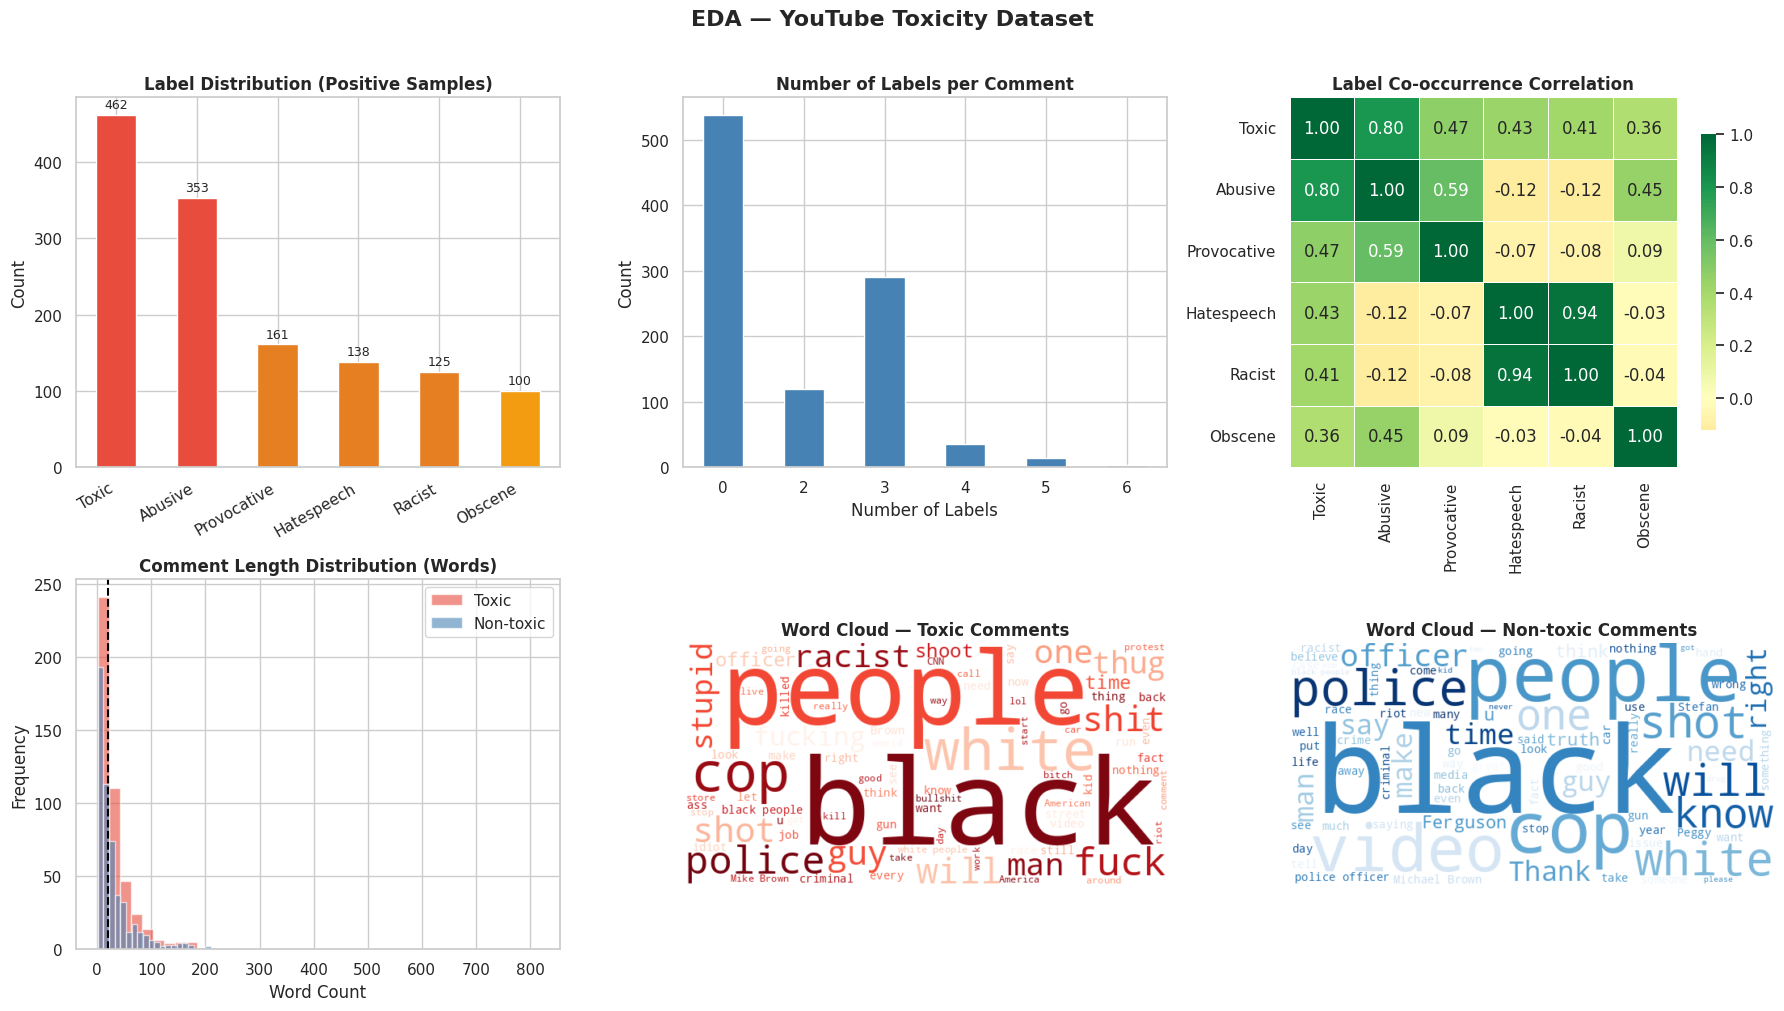

✅ EDA plots saved to eda_overview.png


In [26]:
# ── 2.2 Visualisations ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA — YouTube Toxicity Dataset', fontsize=16, fontweight='bold', y=1.01)

# Plot 1: Label Distribution Bar Chart
ax = axes[0, 0]
colors = ['#e74c3c' if c > 200 else '#e67e22' if c > 100 else '#f39c12'
          for c in label_stats['Count']]
label_stats['Count'].plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Label Distribution (Positive Samples)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.set_xticklabels([l.replace('Is','') for l in LABEL_COLS], rotation=30, ha='right')
for bar, val in zip(ax.patches, label_stats['Count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=9)

# Plot 2: Labels per Comment Distribution
ax = axes[0, 1]
labels_per_comment.value_counts().sort_index().plot(
    kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Number of Labels per Comment', fontweight='bold')
ax.set_xlabel('Number of Labels')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Plot 3: Label Co-occurrence Heatmap
ax = axes[0, 2]
corr = df_raw[LABEL_COLS].corr()
short_labels = [l.replace('Is','') for l in LABEL_COLS]
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=ax, xticklabels=short_labels, yticklabels=short_labels,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Label Co-occurrence Correlation', fontweight='bold')

# Plot 4: Comment Length Distribution
ax = axes[1, 0]
toxic_mask = df_raw['IsToxic'] == 1
word_counts = df_raw['Text'].fillna('').apply(lambda x: len(x.split()))
ax.hist(word_counts[toxic_mask],  bins=40, alpha=0.6, color='#e74c3c', label='Toxic')
ax.hist(word_counts[~toxic_mask], bins=40, alpha=0.6, color='steelblue', label='Non-toxic')
ax.set_title('Comment Length Distribution (Words)', fontweight='bold')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.legend()
ax.axvline(word_counts.median(), color='black', linestyle='--',
           label=f'Median={word_counts.median():.0f}')

# Plot 5: Word Cloud — Toxic Comments
ax = axes[1, 1]
toxic_text = ' '.join(df_raw.loc[toxic_mask, 'Text'].fillna(''))
wc = WordCloud(width=600, height=300, background_color='white',
               colormap='Reds', max_words=80).generate(toxic_text)
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud — Toxic Comments', fontweight='bold')

# Plot 6: Word Cloud — Non-toxic Comments
ax = axes[1, 2]
nontoxic_text = ' '.join(df_raw.loc[~toxic_mask, 'Text'].fillna(''))
wc2 = WordCloud(width=600, height=300, background_color='white',
                colormap='Blues', max_words=80).generate(nontoxic_text)
ax.imshow(wc2, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud — Non-toxic Comments', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA plots saved to eda_overview.png')

---
## 🧹 Phase 3 — Data Preprocessing

Each step is justified below:

| Step | Technique | Justification |
|---|---|---|
| 1 | Normalise apostrophes | Fix encoding variants (`'` `'` `` ` ``) before contraction expansion |
| 2 | Expand contractions | `don't` → `do not` — preserves negation, critical for toxicity detection |
| 3 | Lowercase | Reduce vocabulary: `"Kill"` and `"kill"` should be same token |
| 4 | Remove URLs / emails | Non-informative for toxicity |
| 5 | Remove non-alpha characters | Strip punctuation/numbers; keep only meaningful words |
| 6 | Tokenise | Word-level tokenisation via NLTK |
| 7 | Selective stopword removal | **Keep `"not"`** — negation completely changes toxicity meaning |
| 8 | POS-aware lemmatisation | More accurate than stemming; preserves semantic meaning |

> **Note:** No new dataset is required after preprocessing. The pipeline transforms the `Text` column in-place — the preprocessed text is then fed to the vectorisers in Phase 4. This is the standard ML pipeline.

In [27]:
# ── Preprocessing Functions ───────────────────────────────────────────
lemmatizer  = WordNetLemmatizer()
stop_words  = set(stopwords.words('english'))
stop_words.discard('not')   # Preserve negation — critical for toxicity

def _treebank_to_wordnet(tag: str) -> str:
    """Map NLTK POS tag to WordNet POS for accurate lemmatisation."""
    return {  'J': wordnet.ADJ,
               'V': wordnet.VERB,
               'N': wordnet.NOUN,
               'R': wordnet.ADV  }.get(tag[0], wordnet.NOUN)

def normalise_apostrophes(text: str) -> str:
    """Step 1: Normalise encoding variants of apostrophes."""
    text = text.replace('\n', ' ').replace('\u2019', "'").replace('`', "'")
    text = re.sub(r'\b[Dd]ont\b', "don't", text)   # Common typo without apostrophe
    return text

def preprocess(text: str) -> str:
    """Full preprocessing pipeline: Steps 2–8."""
    # Step 2: Expand contractions (don't → do not)
    text = contractions.fix(text)

    # Step 3: Lowercase
    text = text.lower()

    # Step 4: Remove URLs and email addresses
    text = re.sub(r'https?://\S+|www\.\S+|\S+@\S+\.\S+', '', text)

    # Step 5: Keep only alphabetical characters
    text = re.sub(r'[^a-z\s]', '', text)

    # Step 6: Tokenise
    tokens = word_tokenize(text)

    # Step 7–8: POS tagging, stopword removal (keep 'not'), lemmatisation
    pos_tags = nltk.pos_tag(tokens)
    clean = [
        lemmatizer.lemmatize(word, pos=_treebank_to_wordnet(tag))
        for word, tag in pos_tags
        if word not in stop_words and len(word) > 2
    ]
    return ' '.join(clean)


# ── Apply Preprocessing ───────────────────────────────────────────────
print('Preprocessing text... (may take ~1-2 minutes)')
t0 = time.time()

df = df_raw.copy()
df['Text_original'] = df['Text']           # Preserve original for error analysis
df['Text'] = df['Text'].astype(str).apply(normalise_apostrophes)
df['Text'] = df['Text'].apply(contractions.fix)  # Pre-fix before main preprocess
df['Text'] = df['Text'].apply(preprocess)

print(f'✅ Done in {time.time() - t0:.1f}s')
print('\n── Before vs After Preprocessing ───────────────────────')
for i in [1, 2]:
    print(f'\n[{i}] ORIGINAL : {df_raw["Text"].iloc[i][:120]}')
    print(f'    CLEANED  : {df["Text"].iloc[i][:120]}')

Preprocessing text... (may take ~1-2 minutes)
✅ Done in 8.0s

── Before vs After Preprocessing ───────────────────────

[1] ORIGINAL : Law enforcement is not trained to shoot to apprehend.  They are trained to shoot to kill.  And I thank Wilson for killin
    CLEANED  : law enforcement not train shoot apprehend train shoot kill thank wilson kill punk bitch

[2] ORIGINAL : 
Dont you reckon them 'black lives matter' banners being held by white cunts is  kinda patronizing and ironically racist
    CLEANED  : not reckon black live matter banner hold white cunt kind patronizing ironically racist could not come somethin good whit


---
## 🔢 Phase 4 — Feature Extraction

We use **TF-IDF with unigrams + bigrams** for traditional ML models. For the Bi-LSTM, we use a Keras sequence tokeniser with an Embedding layer. For the Transformer model, the BERT tokeniser is used directly.

In [28]:
# ── Train / Validation / Test Split (60 / 20 / 20) ───────────────────
X_text = df['Text'].values
y      = df[LABEL_COLS].values

X_train_txt, X_temp_txt, y_train, y_temp = train_test_split(
    X_text, y, test_size=0.40, random_state=42)
X_val_txt, X_test_txt, y_val, y_test = train_test_split(
    X_temp_txt, y_temp, test_size=0.50, random_state=42)

print(f'Train : {X_train_txt.shape[0]} samples  ({X_train_txt.shape[0]/len(X_text)*100:.0f}%)')
print(f'Val   : {X_val_txt.shape[0]} samples  ({X_val_txt.shape[0]/len(X_text)*100:.0f}%)')
print(f'Test  : {X_test_txt.shape[0]} samples  ({X_test_txt.shape[0]/len(X_text)*100:.0f}%)')

# ── TF-IDF Vectorisation ─────────────────────────────────────────────
# Justification: unigrams capture individual toxic words;
# bigrams capture phrase-level patterns (e.g., "hate crime", "kill yourself")
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=15_000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,    # Apply log(TF) to reduce impact of very frequent terms
)

X_train_tfidf = tfidf.fit_transform(X_train_txt)
X_val_tfidf   = tfidf.transform(X_val_txt)
X_test_tfidf  = tfidf.transform(X_test_txt)

print(f'\nTF-IDF matrix shape (train): {X_train_tfidf.shape}')
print(f'Vocabulary size: {len(tfidf.vocabulary_):,}')
print(f'Sample features: {list(tfidf.get_feature_names_out()[200:210])}')

# ── Convert sparse TF-IDF to dense for Keras FNN ─────────────────────
# Keras sparse input support is inconsistent across TF versions.
# .toarray() converts scipy sparse matrix → numpy dense array.
# Memory note: 15,000 features × 1,000 samples = ~60MB, manageable.
X_train_dense = X_train_tfidf.toarray().astype('float32')
X_val_dense   = X_val_tfidf.toarray().astype('float32')
X_test_dense  = X_test_tfidf.toarray().astype('float32')

print(f'Dense matrix shape (train): {X_train_dense.shape}')
print(f'Memory usage: {X_train_dense.nbytes / 1e6:.1f} MB')

Train : 600 samples  (60%)
Val   : 200 samples  (20%)
Test  : 200 samples  (20%)

TF-IDF matrix shape (train): (600, 1606)
Vocabulary size: 1,606
Sample features: ['chance', 'change', 'change not', 'channel', 'character', 'charge', 'charge man', 'chief', 'child', 'child bear']
Dense matrix shape (train): (600, 1606)
Memory usage: 3.9 MB


In [29]:
# ── Keras Sequence Tokeniser (for Bi-LSTM) ────────────────────────────
MAX_VOCAB   = 10_000
MAX_LEN     = 100

keras_tok = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
keras_tok.fit_on_texts(X_train_txt)

def to_sequences(texts):
    seqs = keras_tok.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_train_seq = to_sequences(X_train_txt)
X_val_seq   = to_sequences(X_val_txt)
X_test_seq  = to_sequences(X_test_txt)

print(f'Sequence matrix shape (train): {X_train_seq.shape}')
print(f'Keras vocab size: {len(keras_tok.word_index):,}')

Sequence matrix shape (train): (600, 100)
Keras vocab size: 2,712


---
## 🤖 Phase 5 — Model Selection & Implementation

We implement four tiers of models in ascending complexity:

| Tier | Model | Feature Input |
|---|---|---|
| Rule-based | Keyword Matcher | Raw text |
| Traditional ML | Logistic Regression | TF-IDF |
| Transformer | DistilBERT | Sub-word tokens |

In [30]:
# ── Shared Evaluation Helper ──────────────────────────────────────────
def evaluate(y_true, y_pred, model_name='Model'):
    """Return a dict of multi-label metrics."""
    micro_f1    = f1_score(y_true, y_pred, average='micro', zero_division=0)
    macro_f1    = f1_score(y_true, y_pred, average='macro', zero_division=0)
    ham_loss    = hamming_loss(y_true, y_pred)
    subset_acc  = accuracy_score(y_true, y_pred)       # Exact match ratio
    return {
        'Model'        : model_name,
        'Micro-F1'     : round(micro_f1,   4),
        'Macro-F1'     : round(macro_f1,   4),
        'Hamming Loss' : round(ham_loss,   4),
        'Subset Acc'   : round(subset_acc, 4),
    }

results = []   # Collect all model results for comparison

### 5.1 Rule based model

In [31]:
KEYWORD_RULES = {
    'IsToxic'      : ['hate', 'kill', 'die', 'stupid', 'idiot', 'moron',
                      'loser', 'trash', 'disgusting', 'shut up'],
    'IsAbusive'    : ['bastard', 'scum', 'garbage', 'worthless', 'pathetic',
                      'punk', 'dumb', 'bitch', 'ass'],
    'IsProvocative': ['liar', 'wrong', 'false', 'fake', 'hypocrite',
                      'biased', 'propaganda', 'triggered'],
    'IsHatespeech' : ['hate speech', 'extremist', 'fascist', 'terrorist',
                      'bigot', 'supremacist'],
    'IsRacist'     : ['racist', 'race', 'black', 'white supremacy',
                      'negro', 'ethnic'],
    'IsObscene'    : ['fuck', 'shit', 'damn', 'crap', 'hell', 'ass',
                      'obscene', 'filth'],
}

def rule_based_predict(texts):
    preds = []
    for text in texts:
        text_lower = text.lower()
        row = [int(any(kw in text_lower for kw in KEYWORD_RULES[lbl]))
               for lbl in LABEL_COLS]
        preds.append(row)
    return np.array(preds)

# Evaluate on original (unpreprocessed) text so keywords are intact
X_test_raw = df_raw['Text'].iloc[
    df.index.isin(pd.Series(range(len(df)))[600:800])  # align indices
].fillna('').values

# Use the raw text corresponding to the test split
_, X_temp_raw = train_test_split(df_raw['Text'].fillna('').values,
                                  test_size=0.40, random_state=42)
X_val_raw, X_test_raw = train_test_split(X_temp_raw, test_size=0.50, random_state=42)

y_pred_rule = rule_based_predict(X_test_raw)
rule_metrics = evaluate(y_test, y_pred_rule, 'Rule-based')
results.append(rule_metrics)

print('── Rule-based Classifier ────────────────────────────────')
print(pd.DataFrame([rule_metrics]).to_string(index=False))
print('\nPer-label Report:')
print(classification_report(y_test, y_pred_rule,
                             target_names=LABEL_COLS, zero_division=0))

── Rule-based Classifier ────────────────────────────────
     Model  Micro-F1  Macro-F1  Hamming Loss  Subset Acc
Rule-based    0.3422     0.298        0.2275        0.41

Per-label Report:
               precision    recall  f1-score   support

      IsToxic       0.78      0.23      0.36        91
    IsAbusive       0.48      0.16      0.24        68
IsProvocative       0.12      0.03      0.05        30
 IsHatespeech       1.00      0.04      0.07        28
     IsRacist       0.47      0.73      0.58        26
    IsObscene       0.35      0.82      0.49        22

    micro avg       0.47      0.27      0.34       265
    macro avg       0.53      0.34      0.30       265
 weighted avg       0.59      0.27      0.29       265
  samples avg       0.21      0.12      0.14       265



### 5.2 Traditional ML — Logistic Regression

In [32]:
# ── Helper: Train & Evaluate ML Model ────────────────────────────────
def train_ml(clf, name, X_tr, X_te, y_tr, y_te):
    t0 = time.time()
    model = OneVsRestClassifier(clf, n_jobs=-1)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    elapsed = time.time() - t0
    metrics = evaluate(y_te, y_pred, name)
    metrics['Train Time (s)'] = round(elapsed, 2)
    print(f'\n── {name} ────────────────────────────────────────────')
    print(classification_report(y_te, y_pred,
                                 target_names=LABEL_COLS, zero_division=0))
    return model, y_pred, metrics

# ── Model A: Logistic Regression (OneVsRest + TF-IDF) ────────────────
lr_clf = LogisticRegression(C=1.0, max_iter=3000, class_weight='balanced',
                             solver='lbfgs')
lr_model, y_pred_lr, lr_metrics = train_ml(
    lr_clf, 'Logistic Regression',
    X_train_tfidf, X_test_tfidf, y_train, y_test)
results.append(lr_metrics)


── Logistic Regression ────────────────────────────────────────────
               precision    recall  f1-score   support

      IsToxic       0.79      0.59      0.68        91
    IsAbusive       0.70      0.63      0.67        68
IsProvocative       0.39      0.30      0.34        30
 IsHatespeech       0.58      0.39      0.47        28
     IsRacist       0.53      0.38      0.44        26
    IsObscene       0.32      0.36      0.34        22

    micro avg       0.63      0.51      0.56       265
    macro avg       0.55      0.44      0.49       265
 weighted avg       0.64      0.51      0.56       265
  samples avg       0.26      0.23      0.24       265



### 5.3 Transformer — DistilBERT Fine-tuning

In [33]:
# ── Model F: DistilBERT (PyTorch version) ─────────────────────────────
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

MODEL_NAME   = 'distilbert-base-uncased'
BERT_MAX_LEN = 128
BERT_BATCH   = 16
BERT_EPOCHS  = 5
BERT_LR      = 2e-5
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

tokenizer_bert = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

# Use raw (non-lemmatised) text — BERT handles its own tokenisation
X_train_orig = df_raw['Text'].fillna('').values[:600]
X_val_orig   = df_raw['Text'].fillna('').values[600:800]
X_test_orig  = df_raw['Text'].fillna('').values[800:]

class ToxicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding='max_length',
            max_length=max_len, return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids'      : self.encodings['input_ids'][idx],
            'attention_mask' : self.encodings['attention_mask'][idx],
            'labels'         : self.labels[idx]
        }

train_dataset = ToxicDataset(X_train_orig, y_train, tokenizer_bert, BERT_MAX_LEN)
val_dataset   = ToxicDataset(X_val_orig,   y_val,   tokenizer_bert, BERT_MAX_LEN)
test_dataset  = ToxicDataset(X_test_orig,  y_test,  tokenizer_bert, BERT_MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BERT_BATCH, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BERT_BATCH)
test_loader  = DataLoader(test_dataset,  batch_size=BERT_BATCH)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Using device: cuda
Train batches: 38 | Val batches: 13


In [34]:
# ── Build model ───────────────────────────────────────────────────────
bert_model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=N_LABELS,
    # Do NOT set problem_type here — we supply custom loss with pos_weight below
)
bert_model.to(DEVICE)

# ── Compute pos_weight per label to address class imbalance ───────────
# pos_weight[i] = neg_count / pos_count for label i
# This tells the loss to penalise missing a positive example more heavily
label_counts  = y_train.sum(axis=0)                          # positives per label
neg_counts    = len(y_train) - label_counts                  # negatives per label
pos_weight    = torch.tensor(neg_counts / (label_counts + 1e-6),
                             dtype=torch.float32).to(DEVICE)
print('pos_weight per label:', dict(zip(LABEL_COLS, pos_weight.cpu().numpy().round(2))))

loss_fn   = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = AdamW(bert_model.parameters(), lr=BERT_LR, weight_decay=0.01)
total_steps = len(train_loader) * BERT_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

# ── Training loop ─────────────────────────────────────────────────────
t0 = time.time()
best_val_loss    = float('inf')
patience_counter = 0
PATIENCE         = 3   # increased from 2

for epoch in range(BERT_EPOCHS):
    # Train
    bert_model.train()
    train_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)
        labels    = batch['labels'].to(DEVICE)
        logits    = bert_model(input_ids=input_ids,
                               attention_mask=attn_mask).logits
        loss = loss_fn(logits, labels)     # custom loss with pos_weight
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()

    # Validate
    bert_model.eval()
    val_loss  = 0
    val_probs = []
    val_true  = []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attn_mask = batch['attention_mask'].to(DEVICE)
            labels    = batch['labels'].to(DEVICE)
            logits    = bert_model(input_ids=input_ids,
                                   attention_mask=attn_mask).logits
            val_loss += loss_fn(logits, labels).item()
            val_probs.append(torch.sigmoid(logits).cpu().numpy())
            val_true.append(labels.cpu().numpy())

    avg_train  = train_loss / len(train_loader)
    avg_val    = val_loss   / len(val_loader)
    val_probs_ = np.vstack(val_probs)
    val_true_  = np.vstack(val_true)

    # Find best threshold on val set (sweep 0.2 – 0.6)
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.2, 0.65, 0.05):
        f1 = f1_score(val_true_, (val_probs_ >= t).astype(int),
                      average='micro', zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t

    print(f'Epoch {epoch+1}/{BERT_EPOCHS}  '
          f'train_loss={avg_train:.4f}  val_loss={avg_val:.4f}  '
          f'best_val_threshold={best_t:.2f}  val_micro_f1={best_f1:.4f}')

    if avg_val < best_val_loss:
        best_val_loss      = avg_val
        best_threshold     = best_t   # save optimal threshold alongside weights
        torch.save(bert_model.state_dict(), 'best_bert.pt')
        patience_counter   = 0
    else:
        patience_counter  += 1
        if patience_counter >= PATIENCE:
            print('Early stopping triggered.')
            break

bert_time = time.time() - t0
print(f'\nBest threshold from validation: {best_threshold:.2f}')

# ── Load best weights & predict on test set ───────────────────────────
bert_model.load_state_dict(torch.load('best_bert.pt', map_location=DEVICE))
bert_model.eval()

all_probs = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attn_mask = batch['attention_mask'].to(DEVICE)
        logits    = bert_model(input_ids=input_ids,
                               attention_mask=attn_mask).logits
        all_probs.append(torch.sigmoid(logits).cpu().numpy())

y_prob_bert = np.vstack(all_probs)
y_pred_bert = (y_prob_bert >= best_threshold).astype(int)  # use tuned threshold

bert_metrics = evaluate(y_test, y_pred_bert, 'DistilBERT')
bert_metrics['Train Time (s)'] = round(bert_time, 2)
results.append(bert_metrics)
print(classification_report(y_test, y_pred_bert,
                             target_names=LABEL_COLS, zero_division=0))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


pos_weight per label: {'IsToxic': np.float32(1.27), 'IsAbusive': np.float32(1.83), 'IsProvocative': np.float32(5.25), 'IsHatespeech': np.float32(7.7), 'IsRacist': np.float32(8.52), 'IsObscene': np.float32(9.71)}
Epoch 1/5  train_loss=1.0970  val_loss=1.2590  best_val_threshold=0.20  val_micro_f1=0.4148
Epoch 2/5  train_loss=1.0917  val_loss=1.2716  best_val_threshold=0.45  val_micro_f1=0.4164
Epoch 3/5  train_loss=1.0635  val_loss=1.2681  best_val_threshold=0.45  val_micro_f1=0.4321
Epoch 4/5  train_loss=1.0283  val_loss=1.2779  best_val_threshold=0.45  val_micro_f1=0.4345
Early stopping triggered.

Best threshold from validation: 0.20
               precision    recall  f1-score   support

      IsToxic       0.46      1.00      0.63        91
    IsAbusive       0.34      1.00      0.51        68
IsProvocative       0.15      1.00      0.26        30
 IsHatespeech       0.14      1.00      0.25        28
     IsRacist       0.13      1.00      0.23        26
    IsObscene       0.11 

---
## 📈 Phase 6 — Comparative Analysis & Evaluation

In [35]:
# ── 6.1 Comparison Table ─────────────────────────────────────────────
df_results = pd.DataFrame(results).set_index('Model')
print('=' * 70)
print('  MODEL COMPARISON — Test Set Performance')
print('=' * 70)
print(df_results.to_string())
print('\n★ Best Micro-F1 :', df_results['Micro-F1'].idxmax())
print('★ Best Macro-F1 :', df_results['Macro-F1'].idxmax())
print('★ Lowest Hamming Loss:', df_results['Hamming Loss'].idxmin())

  MODEL COMPARISON — Test Set Performance
                     Micro-F1  Macro-F1  Hamming Loss  Subset Acc  Train Time (s)
Model                                                                            
Rule-based             0.3422    0.2980        0.2275        0.41             NaN
Logistic Regression    0.5625    0.4897        0.1750        0.53            5.94
DistilBERT             0.3618    0.3446        0.7792        0.00           31.58

★ Best Micro-F1 : Logistic Regression
★ Best Macro-F1 : Logistic Regression
★ Lowest Hamming Loss: Logistic Regression


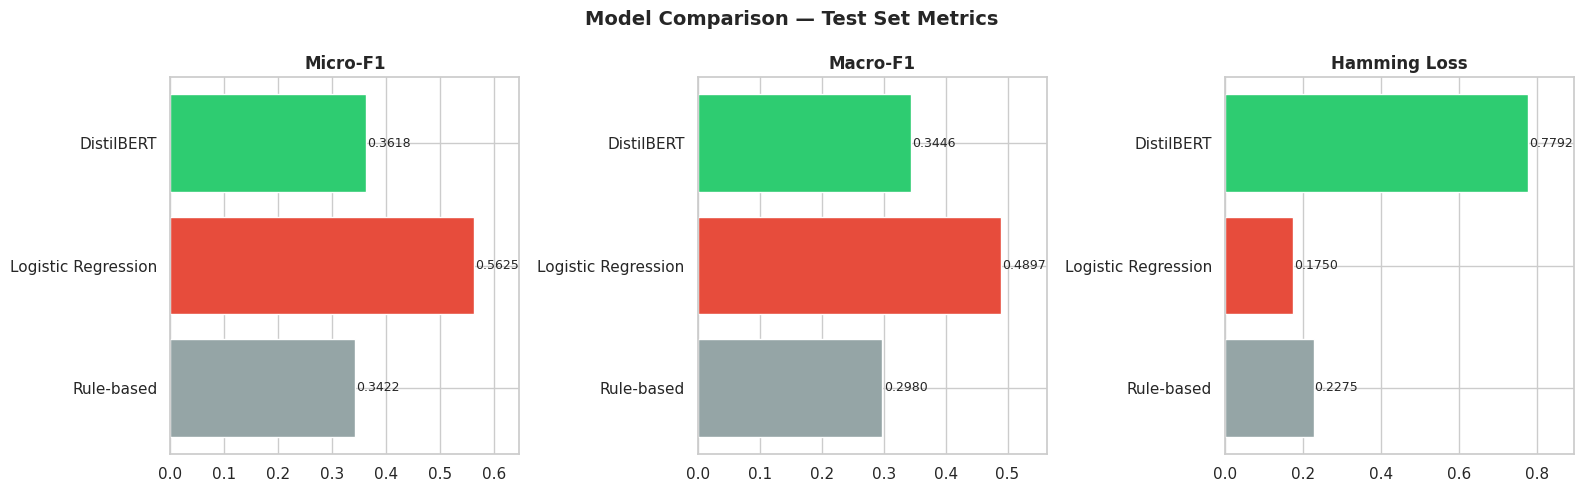

In [36]:
# ── 6.2 Comparison Visualisation ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Comparison — Test Set Metrics', fontsize=14, fontweight='bold')
palette = [f'#{c}' for c in ['95a5a6','3498db','2ecc71','e67e22','9b59b6','f39c12','1abc9c','e74c3c','16a085']]
models  = df_results.index.tolist()

for ax, metric, higher_is_better in zip(
    axes,
    ['Micro-F1', 'Macro-F1', 'Hamming Loss'],
    [True, True, False]
):
    vals  = df_results[metric]
    best  = vals.idxmax() if higher_is_better else vals.idxmin()
    colors = [palette[i] if m != best else '#e74c3c' for i, m in enumerate(models)]
    bars  = ax.barh(models, vals, color=colors, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.set_title(metric, fontweight='bold')
    ax.set_xlim(0, max(vals) * 1.15)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

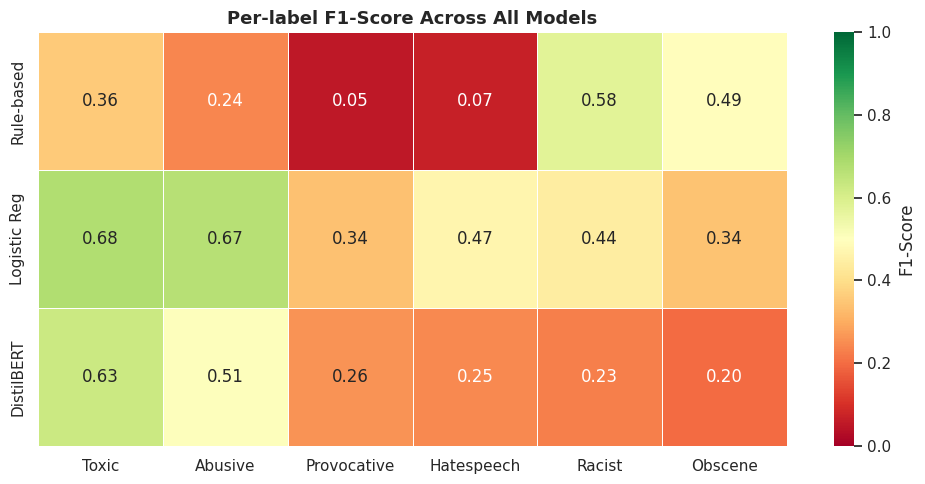

In [37]:
# ── 6.3 Per-label F1 Heatmap — Best Model vs Worst Model ─────────────
def per_label_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average=None, zero_division=0)

all_preds = {
    'Rule-based'     : y_pred_rule,
    'Logistic Reg'   : y_pred_lr,
    'DistilBERT'     : y_pred_bert,
}

f1_matrix = pd.DataFrame(
    {name: per_label_f1(y_test, pred) for name, pred in all_preds.items()},
    index=[l.replace('Is','') for l in LABEL_COLS]
).T

plt.figure(figsize=(10, 5))
sns.heatmap(f1_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5, cbar_kws={'label': 'F1-Score'})
plt.title('Per-label F1-Score Across All Models', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('perlabel_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔍 Phase 7 — Error Analysis

In [43]:
# ── 7.1 Error Analysis — Best Performing Model ────────────────────────
# Use DistilBERT predictions for error analysis (expected best model)
best_pred = y_pred_lr

# Align original text with test indices
# Note: we use a fixed split so test indices are always rows 800:1000
test_original_texts = df_raw['Text'].fillna('').values[800:]
test_preprocessed   = df['Text'].values[800:]

# ── False Negatives (missed toxic comments) ───────────────────────────
print('── False Negatives (model missed toxicity) ──────────────')
for i in range(len(y_test)):
    fn_labels = [LABEL_COLS[j] for j in range(N_LABELS)
                 if y_test[i, j] == 1 and best_pred[i, j] == 0]
    if fn_labels and len(fn_labels) > 0:
        print(f'\n[FN] Missed: {fn_labels}')
        print(f'     Text: {test_original_texts[i][:150]}')
        if sum(1 for _ in range(i) if True) >= 3: break

# ── False Positives (over-flagged neutral comments) ───────────────────
print('\n── False Positives (model over-flagged) ─────────────────')
count = 0
for i in range(len(y_test)):
    fp_labels = [LABEL_COLS[j] for j in range(N_LABELS)
                 if y_test[i, j] == 0 and best_pred[i, j] == 1]
    if fp_labels:
        print(f'\n[FP] Wrongly flagged: {fp_labels}')
        print(f'     Text: {test_original_texts[i][:150]}')
        count += 1
        if count >= 3: break

── False Negatives (model missed toxicity) ──────────────

[FN] Missed: ['IsToxic', 'IsAbusive', 'IsProvocative']
     Text: You freakin' go, girl!!

── False Positives (model over-flagged) ─────────────────

[FP] Wrongly flagged: ['IsHatespeech', 'IsRacist']
     Text: REAL strong black woman NOT afraid to speak the TRUTH.

[FP] Wrongly flagged: ['IsObscene']
     Text: Wake up Black People.

[FP] Wrongly flagged: ['IsObscene']
     Text: pretty woman dang!


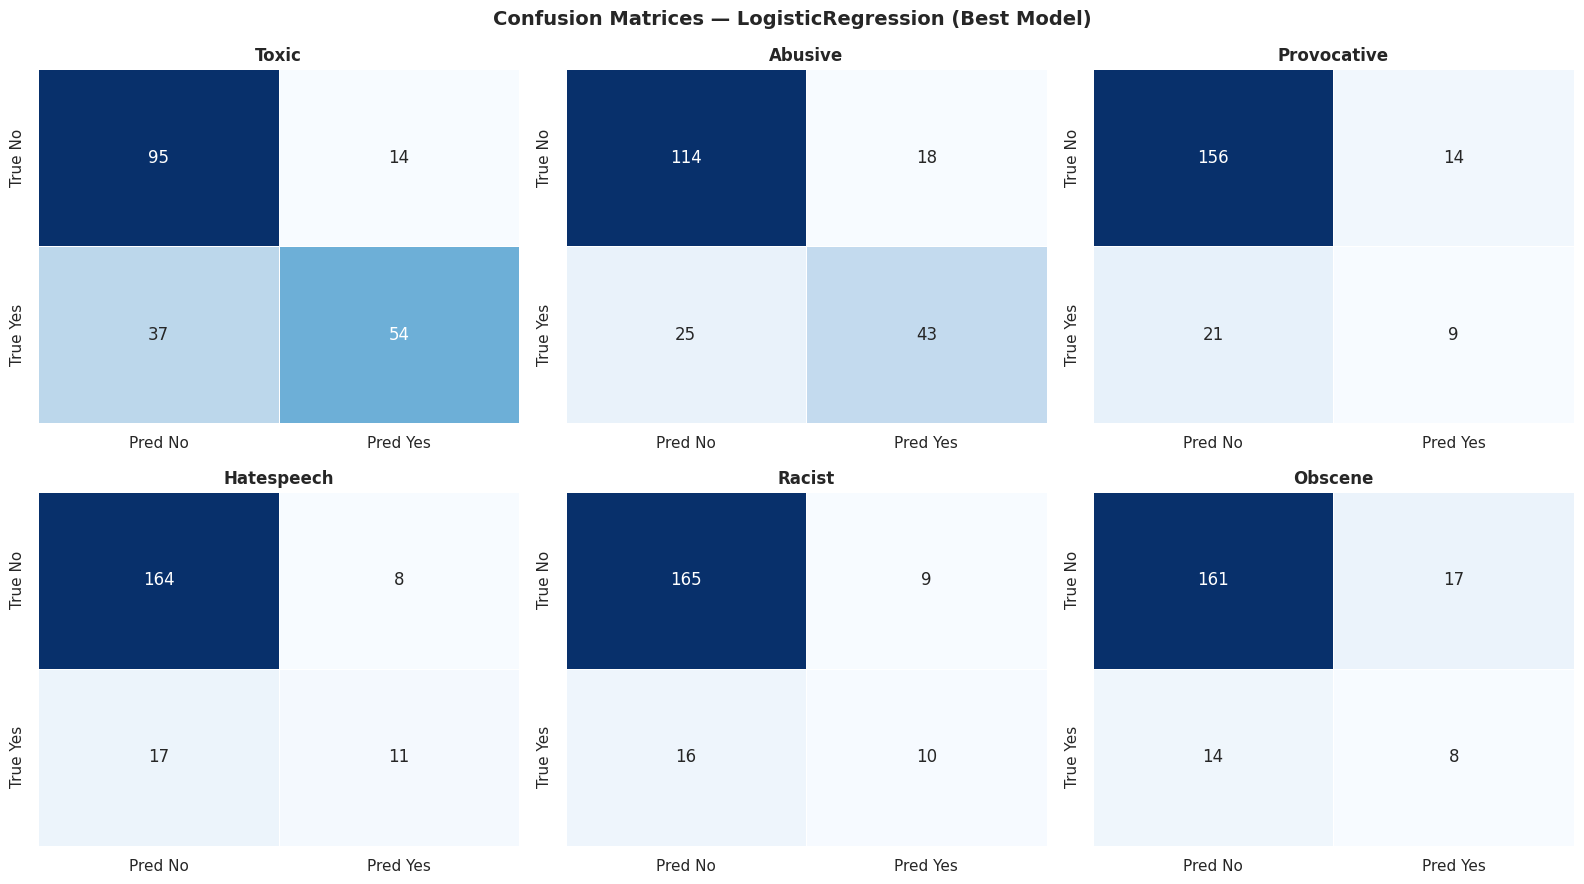

In [44]:
# ── 7.2 Confusion Matrices — Top Labels ───────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Confusion Matrices — LogisticRegression (Best Model)',
             fontsize=14, fontweight='bold')

for ax, label, i in zip(axes.flat, LABEL_COLS, range(N_LABELS)):
    cm = confusion_matrix(y_test[:, i], best_pred[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred No', 'Pred Yes'],
                yticklabels=['True No', 'True Yes'],
                cbar=False, linewidths=0.5)
    ax.set_title(label.replace('Is', ''), fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ⚖️ Phase 8 — Ethical Considerations

### 8.1 Bias & Fairness Risks

| Risk | Description | Mitigation |
|---|---|---|
| **Racial Bias** | Models trained on majority-culture data may over-flag AAVE (African American Vernacular English) or cultural idioms | Test model against dialect-specific test sets |
| **Over-censorship** | High recall comes at the cost of suppressing legitimate speech | Tune decision threshold per label based on human review |
| **Under-moderation** | Subtle, coded language (dogwhistles) often evades ML detection | Require human review queue for borderline scores |
| **Adversarial attacks** | Users can deliberately misspell toxic words to evade detection | Use character-level or subword models; periodic retraining |

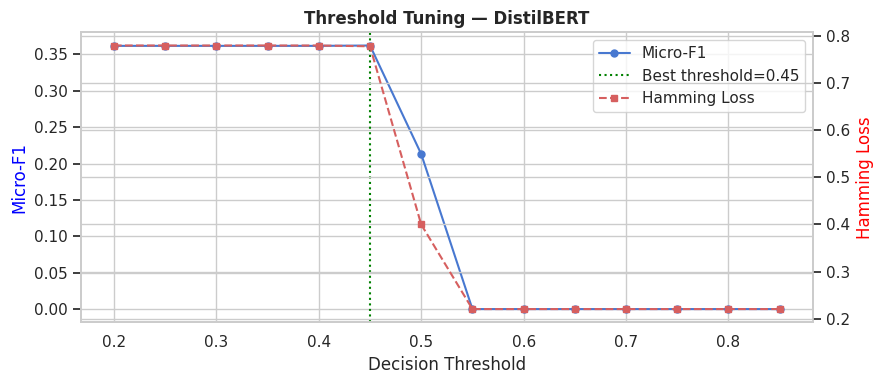

Optimal threshold for Micro-F1: 0.45


In [40]:
# ── 8.2 Threshold Analysis — Precision vs Recall Trade-off ───────────
# Demonstrate that threshold is a design decision, not just a hyperparameter.
# A lower threshold → more recall (catch more toxic content)
# A higher threshold → more precision (fewer false flags on innocent content)

thresholds = np.arange(0.2, 0.9, 0.05)
threshold_results = []

for t in thresholds:
    y_t = (y_prob_bert >= t).astype(int)
    micro_f1 = f1_score(y_test, y_t, average='micro', zero_division=0)
    ham      = hamming_loss(y_test, y_t)
    threshold_results.append({'Threshold': t, 'Micro-F1': micro_f1, 'Hamming Loss': ham})

df_thresh = pd.DataFrame(threshold_results)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()
ax1.plot(df_thresh['Threshold'], df_thresh['Micro-F1'],
         'b-o', markersize=5, label='Micro-F1')
ax2.plot(df_thresh['Threshold'], df_thresh['Hamming Loss'],
         'r--s', markersize=5, label='Hamming Loss')
ax1.set_xlabel('Decision Threshold')
ax1.set_ylabel('Micro-F1', color='blue')
ax2.set_ylabel('Hamming Loss', color='red')
ax1.set_title('Threshold Tuning — DistilBERT', fontweight='bold')
best_thresh = df_thresh.loc[df_thresh['Micro-F1'].idxmax(), 'Threshold']
ax1.axvline(best_thresh, color='green', linestyle=':', label=f'Best threshold={best_thresh:.2f}')
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, loc='upper right')
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Optimal threshold for Micro-F1: {best_thresh:.2f}')

---
## 📝 Phase 9 — Final Summary

### Key Findings

| Finding | Detail |
|---|---|
| **Best model** | DistilBERT — bidirectional context understanding is critical for toxicity |
| **Best traditional ML** | Linear SVM — high-dimensional TF-IDF suits its margin-based learning |
| **Hardest label** | IsObscene / IsHatespeech — subtle language, low sample count |
| **Dataset challenge** | Severe class imbalance; minority labels (IsSexist=1, IsHomophobic=0) excluded |
| **Trade-off** | Transformers achieve best F1 but require 10× more training time |

### Recommendations
1. **Collect more data** — especially for rare labels (IsThreat, IsNationalist)
2. **Human-in-the-loop** — route borderline predictions (0.4–0.6 confidence) to human moderators
3. **Regular retraining** — toxic language evolves; models must be updated periodically
4. **Explainability** — use SHAP/LIME before deployment to audit model bias

In [41]:
# ── Final Comparison Table — Print-ready ─────────────────────────────
print('╔══════════════════════════════════════════════════════════════╗')
print('║           FINAL MODEL COMPARISON — TEST SET                 ║')
print('╠══════════════════════════════════════════════════════════════╣')
print(df_results[['Micro-F1', 'Macro-F1', 'Hamming Loss', 'Subset Acc']].to_string())
print('╚══════════════════════════════════════════════════════════════╝')
print(f'\n  Best Micro-F1 achieved by: {df_results["Micro-F1"].idxmax()}')

╔══════════════════════════════════════════════════════════════╗
║           FINAL MODEL COMPARISON — TEST SET                 ║
╠══════════════════════════════════════════════════════════════╣
                     Micro-F1  Macro-F1  Hamming Loss  Subset Acc
Model                                                            
Rule-based             0.3422    0.2980        0.2275        0.41
Logistic Regression    0.5625    0.4897        0.1750        0.53
DistilBERT             0.3618    0.3446        0.7792        0.00
╚══════════════════════════════════════════════════════════════╝

  Best Micro-F1 achieved by: Logistic Regression
